# Visualisasi Hasil Penelitian CNN FreshScan

Notebook ini membaca seluruh data inferensi dari dua perangkat Android dan menghasilkan visualisasi lengkap untuk bagian **Hasil dan Pembahasan** skripsi.

| Perangkat | Peran |
|---|---|
| **Redmi Note 10 Pro** | **Fokus utama** pengujian inferensi CNN |
| Redmi 9A | Pembanding performa |

Semua grafik tersimpan otomatis ke folder `outputs/visualisasi_skripsi/` dengan resolusi 300 DPI.

## 1. Import Library dan Konfigurasi

In [17]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from IPython.display import display

# ── Path Konfigurasi ─────────────────────────────────────────────────────────
# Jalankan notebook dari folder CnnFreshScanResearch.
ROOT        = Path.cwd()
DATASET_DIR = ROOT / "dataset"
OUTPUT_DIR  = ROOT / "outputs" / "visualisasi_skripsi"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Folder 'tanpa jarak' per perangkat
PATH_9A    = DATASET_DIR / "Redmi 9A"           / "tanpa jarak"
PATH_NOTE  = DATASET_DIR / "Redmi Note 10 Pro"  / "tanpa jarak"

DEVICE_LABELS = {
    "Redmi 9A"          : "Redmi 9A",
    "Redmi Note 10 Pro" : "Redmi Note 10 Pro",
}

# ══════════════════════════════════════════════════════════════════════════════
# HALAMAN KONFIGURASI FONT — UBAH DI SINI UNTUK MENGATUR SEMUA UKURAN
# ══════════════════════════════════════════════════════════════════════════════
FONT_CFG = {
    # ── Judul Grafik ──────────────────────────────────────────────────────
    "title"              : 22,   # Judul utama grafik (sebelumnya 24)
    "suptitle"           : 24,   # Super title (suptitle) untuk multi-panel
    
    # ── Label Sumbu ───────────────────────────────────────────────────────
    "axis_label"         : 30,   # Label sumbu X dan Y (sebelumnya 30)
    
    # ── Tick Labels (Nama Buah/Sayuran) ───────────────────────────────────
    "tick_label"         : 28,   # Label tick sumbu-x/y, NAMA BUAH/SAYURAN (sebelumnya 30)
    
    # ── Anotasi & Data Label ──────────────────────────────────────────────
    "bar_annotation"     : 14,   # Angka di atas bar chart (sebelumnya 17)
    "data_label"         : 16,   # Label data pada grafik (sebelumnya 20)
    "stacked_inside"     : 16,   # Angka di dalam stacked bar (sebelumnya 20)
    "stacked_outside"    : 14,   # Angka "Salah: X" di luar bar
    
    # ── Legend ────────────────────────────────────────────────────────────
    "legend"             : 16,   # Ukuran font legend (sebelumnya 20)
    "legend_title"       : 16,   # Judul legend
    
    # ── Confusion Matrix ──────────────────────────────────────────────────
    "cm_tick"            : 14,   
    "cm_cell"            : 15,   
    "colorbar_label"     : 20,   
    
    # ── Sub-panel (multi-axes) ────────────────────────────────────────────
    "subplot_title"      : 20,   
    "subplot_axis_label" : 20,   
    "subplot_legend"     : 20,   
    
    # ── Confidence Distribution ───────────────────────────────────────────
    "hist_title"         : 20,   
    "hist_axis"          : 20,   
    "hist_legend"        : 20,   
    
    # ── Global rcParams ───────────────────────────────────────────────────
    "global_font"        : 16,   # Ukuran font dasar global (sebelumnya 20)
    "global_title"       : 22,   # axes.titlesize (sebelumnya 24)
    "global_axis"        : 20,   # axes.labelsize (sebelumnya 20)
    "global_tick"        : 18,   # xtick/ytick.labelsize (sebelumnya 20)
    "global_legend"      : 16,   # legend.fontsize (sebelumnya 20)
}

# ── Palette Warna ────────────────────────────────────────────────────────────
PALETTE = {
    "segar"        : "#0072B2",
    "busuk"        : "#D55E00",
    "benar"        : "#009E73",
    "salah"        : "#CC79A7",
    "inference"    : "#56B4E9",
    "rata_rata"    : "#333333",
    "roi"          : "#E69F00",
    "preprocessing": "#F0E442",
    "note10"       : "#2196F3",
    "redmi9a"      : "#FF9800",
}

# ── Matplotlib Style ─────────────────────────────────────────────────────────
plt.style.use("default")
plt.rcParams.update({
    "figure.dpi"       : 150,
    "savefig.dpi"      : 600,
    "font.family"      : "sans-serif",
    "font.sans-serif"  : ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size"        : FONT_CFG["global_font"],
    "axes.titlesize"   : FONT_CFG["global_title"],
    "axes.labelsize"   : FONT_CFG["global_axis"],
    "xtick.labelsize"  : FONT_CFG["global_tick"],
    "ytick.labelsize"  : FONT_CFG["global_tick"],
    "legend.fontsize"  : FONT_CFG["global_legend"],
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.25,
    "grid.linestyle"   : "--",
    "legend.frameon"   : False,
    "axes.linewidth"   : 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size" : 6,
    "ytick.major.size" : 6,
    "lines.linewidth"  : 2.0,
})

print(f"Root     : {ROOT}")
print(f"Dataset  : {DATASET_DIR}")
print(f"Output   : {OUTPUT_DIR}")
print(f"Path 9A  : {PATH_9A}")
print(f"Path Note: {PATH_NOTE}")


Root     : c:\Users\Muhamad Muslih\Desktop\CnnFreshScanResearch
Dataset  : c:\Users\Muhamad Muslih\Desktop\CnnFreshScanResearch\dataset
Output   : c:\Users\Muhamad Muslih\Desktop\CnnFreshScanResearch\outputs\visualisasi_skripsi
Path 9A  : c:\Users\Muhamad Muslih\Desktop\CnnFreshScanResearch\dataset\Redmi 9A\tanpa jarak
Path Note: c:\Users\Muhamad Muslih\Desktop\CnnFreshScanResearch\dataset\Redmi Note 10 Pro\tanpa jarak


## 2. Fungsi Helper & Load Data

In [18]:
ITEM_MAP = {
    "orange"   : "Jeruk",
    "mango"    : "Mangga",
    "banana"   : "Pisang",
    "cucumber" : "Mentimun",
    "tomato"   : "Tomat",
    "carrot"   : "Wortel",
}

def kondisi_from_label(label: str) -> str:
    if "_fresh_" in label:  return "Segar"
    if "_rotten_" in label: return "Busuk"
    return "Tidak Diketahui"

def kategori_from_label(label: str) -> str:
    if label.startswith("fruits_"):     return "Buah"
    if label.startswith("vegetables_"): return "Sayur"
    return "Lainnya"

def komoditas_from_label(label: str) -> str:
    item_key = label.split("_")[-1]
    return ITEM_MAP.get(item_key, item_key.title())

def kelas_from_label(label: str) -> str:
    return f"{komoditas_from_label(label)} {kondisi_from_label(label)}"


def load_device_data(device_path: Path, device_name: str):
    """Baca semua JSON+CSV di device_path dan kembalikan (ringkasan_df, raw_df)."""
    records    = []
    raw_frames = []

    for summary_path in sorted(device_path.glob("*/camera_roi_inference_summary_*.json")):
        with summary_path.open("r", encoding="utf-8") as f:
            summary = json.load(f)

        csv_candidates = sorted(summary_path.parent.glob("camera_roi_inference_report_*.csv"))
        if not csv_candidates:
            continue

        df = pd.read_csv(csv_candidates[0])
        kelas_aktual = kelas_from_label(summary["actualLabel"])

        for col in ["captureIndex", "confidence", "roiCropTimeMs",
                    "preprocessingTimeMs", "inferenceTimeMs", "totalTimeMs"]:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")

        df["isCorrect"]   = df["isCorrect"].astype(str).str.lower().eq("true")
        df["Kelas Aktual"] = kelas_aktual
        df["Perangkat"]   = device_name
        df["Kondisi"]     = kondisi_from_label(summary["actualLabel"])
        df["Kategori"]    = kategori_from_label(summary["actualLabel"])
        df["Komoditas"]   = komoditas_from_label(summary["actualLabel"])
        df["Prediksi Kelas"] = df["predictedLabel"].astype(str).map(kelas_from_label)
        raw_frames.append(df)

        records.append({
            "Perangkat"                 : device_name,
            "Kelas Aktual"              : kelas_aktual,
            "Label Aktual"              : summary["actualLabel"],
            "Kategori"                  : kategori_from_label(summary["actualLabel"]),
            "Komoditas"                 : komoditas_from_label(summary["actualLabel"]),
            "Kondisi"                   : kondisi_from_label(summary["actualLabel"]),
            "Jumlah Capture"            : int(summary["totalCaptures"]),
            "Benar"                     : int(summary["correctPrediction"]),
            "Salah"                     : int(summary["wrongPrediction"]),
            "Akurasi (%)"               : float(summary["accuracy"]) * 100,
            "Rata-rata Inference (ms)"  : float(summary["meanInferenceMs"]),
            "Median Inference (ms)"     : float(summary["medianInferenceMs"]),
            "P95 Inference (ms)"        : float(summary["p95InferenceMs"]),
            "Min Inference (ms)"        : float(summary["minInferenceMs"]),
            "Max Inference (ms)"        : float(summary["maxInferenceMs"]),
            "Rata-rata Preprocessing (ms)": float(summary.get("meanPreprocessingMs", 0)),
            "Rata-rata ROI Crop (ms)"   : float(summary.get("meanRoiCropMs", 0)),
            "Rata-rata Total (ms)"      : float(summary.get("meanTotalMs", 0)),
        })

    raw_df     = pd.concat(raw_frames, ignore_index=True) if raw_frames else pd.DataFrame()
    ringkasan  = pd.DataFrame(records)
    return ringkasan, raw_df


# ── Load kedua perangkat ─────────────────────────────────────────────────────
print("Memuat data Redmi 9A ...")
ring_9a,   raw_9a   = load_device_data(PATH_9A,   "Redmi 9A")
print(f"  → {len(ring_9a)} kelas, {len(raw_9a)} baris")

print("Memuat data Redmi Note 10 Pro ...")
ring_note, raw_note = load_device_data(PATH_NOTE, "Redmi Note 10 Pro")
print(f"  → {len(ring_note)} kelas, {len(raw_note)} baris")

# Gabungkan
ring_all = pd.concat([ring_note, ring_9a], ignore_index=True)   # Note 10 Pro duluan
raw_all  = pd.concat([raw_note,  raw_9a],  ignore_index=True)

# Sort: Komoditas → Kondisi
urutan_kondisi = {"Busuk": 0, "Segar": 1}
for _df in [ring_9a, ring_note, ring_all]:
    _df.sort_values(["Komoditas", "Kondisi"], key=lambda s: s.map(urutan_kondisi) if s.name == "Kondisi" else s,
                    inplace=True, ignore_index=True)
    _df.insert(0, "No", np.arange(1, len(_df) + 1))

# Urutan kelas
KELAS_ORDER = ring_note["Kelas Aktual"].tolist()

print("\nKelas yang dimuat:", KELAS_ORDER)

Memuat data Redmi 9A ...
  → 12 kelas, 1200 baris
Memuat data Redmi Note 10 Pro ...
  → 12 kelas, 1200 baris

Kelas yang dimuat: ['Jeruk Busuk', 'Jeruk Segar', 'Mangga Busuk', 'Mangga Segar', 'Mentimun Busuk', 'Mentimun Segar', 'Pisang Busuk', 'Pisang Segar', 'Tomat Busuk', 'Tomat Segar', 'Wortel Busuk', 'Wortel Segar']


## 3. Fungsi Bantu Visualisasi

In [19]:
def label_wrap(labels, sep=" "):
    return [str(l).replace(sep, "\n") for l in labels]

def warna_kondisi(kondisi):
    return PALETTE["segar"] if kondisi == "Segar" else PALETTE["busuk"]

def warna_perangkat(perangkat):
    return PALETTE["note10"] if "Note" in perangkat else PALETTE["redmi9a"]

def simpan_gambar(fig, nama_file, subdir=""):
    fig.tight_layout()
    save_dir = OUTPUT_DIR / subdir if subdir else OUTPUT_DIR
    save_dir.mkdir(parents=True, exist_ok=True)
    path = save_dir / nama_file
    fig.savefig(path, bbox_inches="tight", facecolor="white", dpi=600, pad_inches=0.3)
    plt.show()
    print(f"  ✓ Disimpan: {path.name}")
    return path

def annotate_bars(ax, bars, values, fmt="{:.1f}", offset=0.8, fs=FONT_CFG["bar_annotation"]):
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + offset,
            fmt.format(val),
            ha="center", va="bottom", fontsize=fs, fontweight="bold"
        )

print("Fungsi bantu visualisasi siap.")


Fungsi bantu visualisasi siap.


## 4. Tabel Ringkasan – Redmi Note 10 Pro (Fokus Utama)

In [20]:
kolom_tabel = ["No", "Kelas Aktual", "Jumlah Capture", "Benar", "Salah",
               "Akurasi (%)", "Rata-rata Inference (ms)", "Median Inference (ms)", "P95 Inference (ms)"]

def format_tabel(df, kolom):
    tbl = df[kolom].copy()
    tbl["Akurasi (%)"]                = tbl["Akurasi (%)"].map(lambda v: f"{v:.2f}%")
    tbl["Rata-rata Inference (ms)"]    = tbl["Rata-rata Inference (ms)"].map(lambda v: f"{v:.2f} ms")
    tbl["Median Inference (ms)"]       = tbl["Median Inference (ms)"].map(lambda v: f"{v:.2f} ms")
    tbl["P95 Inference (ms)"]          = tbl["P95 Inference (ms)"].map(lambda v: f"{v:.2f} ms")
    return tbl

print("=" * 60)
print("Redmi Note 10 Pro – Tabel Ringkasan Hasil Inferensi")
print("=" * 60)
display(format_tabel(ring_note, kolom_tabel))

print("\n" + "=" * 60)
print("Redmi 9A – Tabel Ringkasan (Pembanding)")
print("=" * 60)
display(format_tabel(ring_9a, kolom_tabel))

# Simpan CSV
ring_note[kolom_tabel].to_csv(OUTPUT_DIR / "tabel_ringkasan_note10pro.csv", index=False, encoding="utf-8-sig")
ring_9a  [kolom_tabel].to_csv(OUTPUT_DIR / "tabel_ringkasan_redmi9a.csv",   index=False, encoding="utf-8-sig")
print("\nCSV ringkasan tersimpan.")

Redmi Note 10 Pro – Tabel Ringkasan Hasil Inferensi


,No,Kelas Aktual,Jumlah Capture,Benar,Salah,Akurasi (%),Rata-rata Inference (ms),Median Inference (ms),P95 Inference (ms)
0,1,Jeruk Busuk,100,100,0,100.00%,32.40 ms,28.81 ms,54.25 ms
1,2,Jeruk Segar,100,100,0,100.00%,55.23 ms,51.59 ms,101.37 ms
2,3,Mangga Busuk,100,100,0,100.00%,41.59 ms,39.77 ms,62.16 ms
3,4,Mangga Segar,100,92,8,92.00%,32.81 ms,29.01 ms,55.17 ms
4,5,Mentimun Busuk,100,63,37,63.00%,34.99 ms,32.19 ms,57.16 ms
5,6,Mentimun Segar,100,82,18,82.00%,33.69 ms,30.71 ms,50.54 ms
6,7,Pisang Busuk,100,100,0,100.00%,31.04 ms,26.49 ms,61.88 ms
7,8,Pisang Segar,100,100,0,100.00%,57.99 ms,50.54 ms,115.51 ms
8,9,Tomat Busuk,100,97,3,97.00%,32.60 ms,29.49 ms,48.45 ms
9,10,Tomat Segar,100,100,0,100.00%,32.34 ms,31.14 ms,43.90 ms



Redmi 9A – Tabel Ringkasan (Pembanding)


,No,Kelas Aktual,Jumlah Capture,Benar,Salah,Akurasi (%),Rata-rata Inference (ms),Median Inference (ms),P95 Inference (ms)
0,1,Jeruk Busuk,100,100,0,100.00%,89.97 ms,94.09 ms,119.34 ms
1,2,Jeruk Segar,100,100,0,100.00%,84.24 ms,86.02 ms,114.32 ms
2,3,Mangga Busuk,100,100,0,100.00%,87.82 ms,92.31 ms,120.43 ms
3,4,Mangga Segar,100,96,4,96.00%,84.73 ms,86.42 ms,115.29 ms
4,5,Mentimun Busuk,100,50,50,50.00%,88.46 ms,90.23 ms,122.04 ms
5,6,Mentimun Segar,100,99,1,99.00%,81.14 ms,80.70 ms,117.13 ms
6,7,Pisang Busuk,100,100,0,100.00%,93.64 ms,96.65 ms,127.87 ms
7,8,Pisang Segar,100,100,0,100.00%,81.49 ms,84.36 ms,115.77 ms
8,9,Tomat Busuk,100,92,8,92.00%,96.74 ms,99.75 ms,125.80 ms
9,10,Tomat Segar,100,100,0,100.00%,83.17 ms,86.27 ms,110.97 ms



CSV ringkasan tersimpan.


## 5. Metrik Utama per Perangkat

In [21]:
def metrik_perangkat(ring_df, raw_df, nama):
    total_cap    = int(ring_df["Jumlah Capture"].sum())
    total_benar  = int(ring_df["Benar"].sum())
    total_salah  = int(ring_df["Salah"].sum())
    akurasi      = total_benar / total_cap * 100
    mean_inf     = raw_df["inferenceTimeMs"].mean()
    mean_total   = raw_df["totalTimeMs"].mean()
    return {
        "Perangkat"                      : nama,
        "Total Capture"                  : total_cap,
        "Prediksi Benar"                 : total_benar,
        "Prediksi Salah"                 : total_salah,
        "Akurasi Total (%)"              : f"{akurasi:.2f}%",
        "Rata-rata Inference (ms)"       : f"{mean_inf:.2f} ms",
        "Rata-rata Total Pemrosesan (ms)": f"{mean_total:.2f} ms",
    }

m_note = metrik_perangkat(ring_note, raw_note, "Redmi Note 10 Pro")
m_9a   = metrik_perangkat(ring_9a,   raw_9a,   "Redmi 9A")

metrik_df = pd.DataFrame([m_note, m_9a])
print("Metrik Utama Perbandingan Perangkat")
display(metrik_df)

metrik_df.to_csv(OUTPUT_DIR / "tabel_metrik_perbandingan_perangkat.csv", index=False, encoding="utf-8-sig")

Metrik Utama Perbandingan Perangkat


,Perangkat,Total Capture,Prediksi Benar,Prediksi Salah,Akurasi Total (%),Rata-rata Inference (ms),Rata-rata Total Pemrosesan (ms)
0,Redmi Note 10 Pro,1200,1134,66,94.50%,37.56 ms,55.46 ms
1,Redmi 9A,1200,1132,68,94.33%,86.57 ms,153.08 ms


## 7. Grafik Perbandingan Akurasi Antar Perangkat (Gambar 4.37)


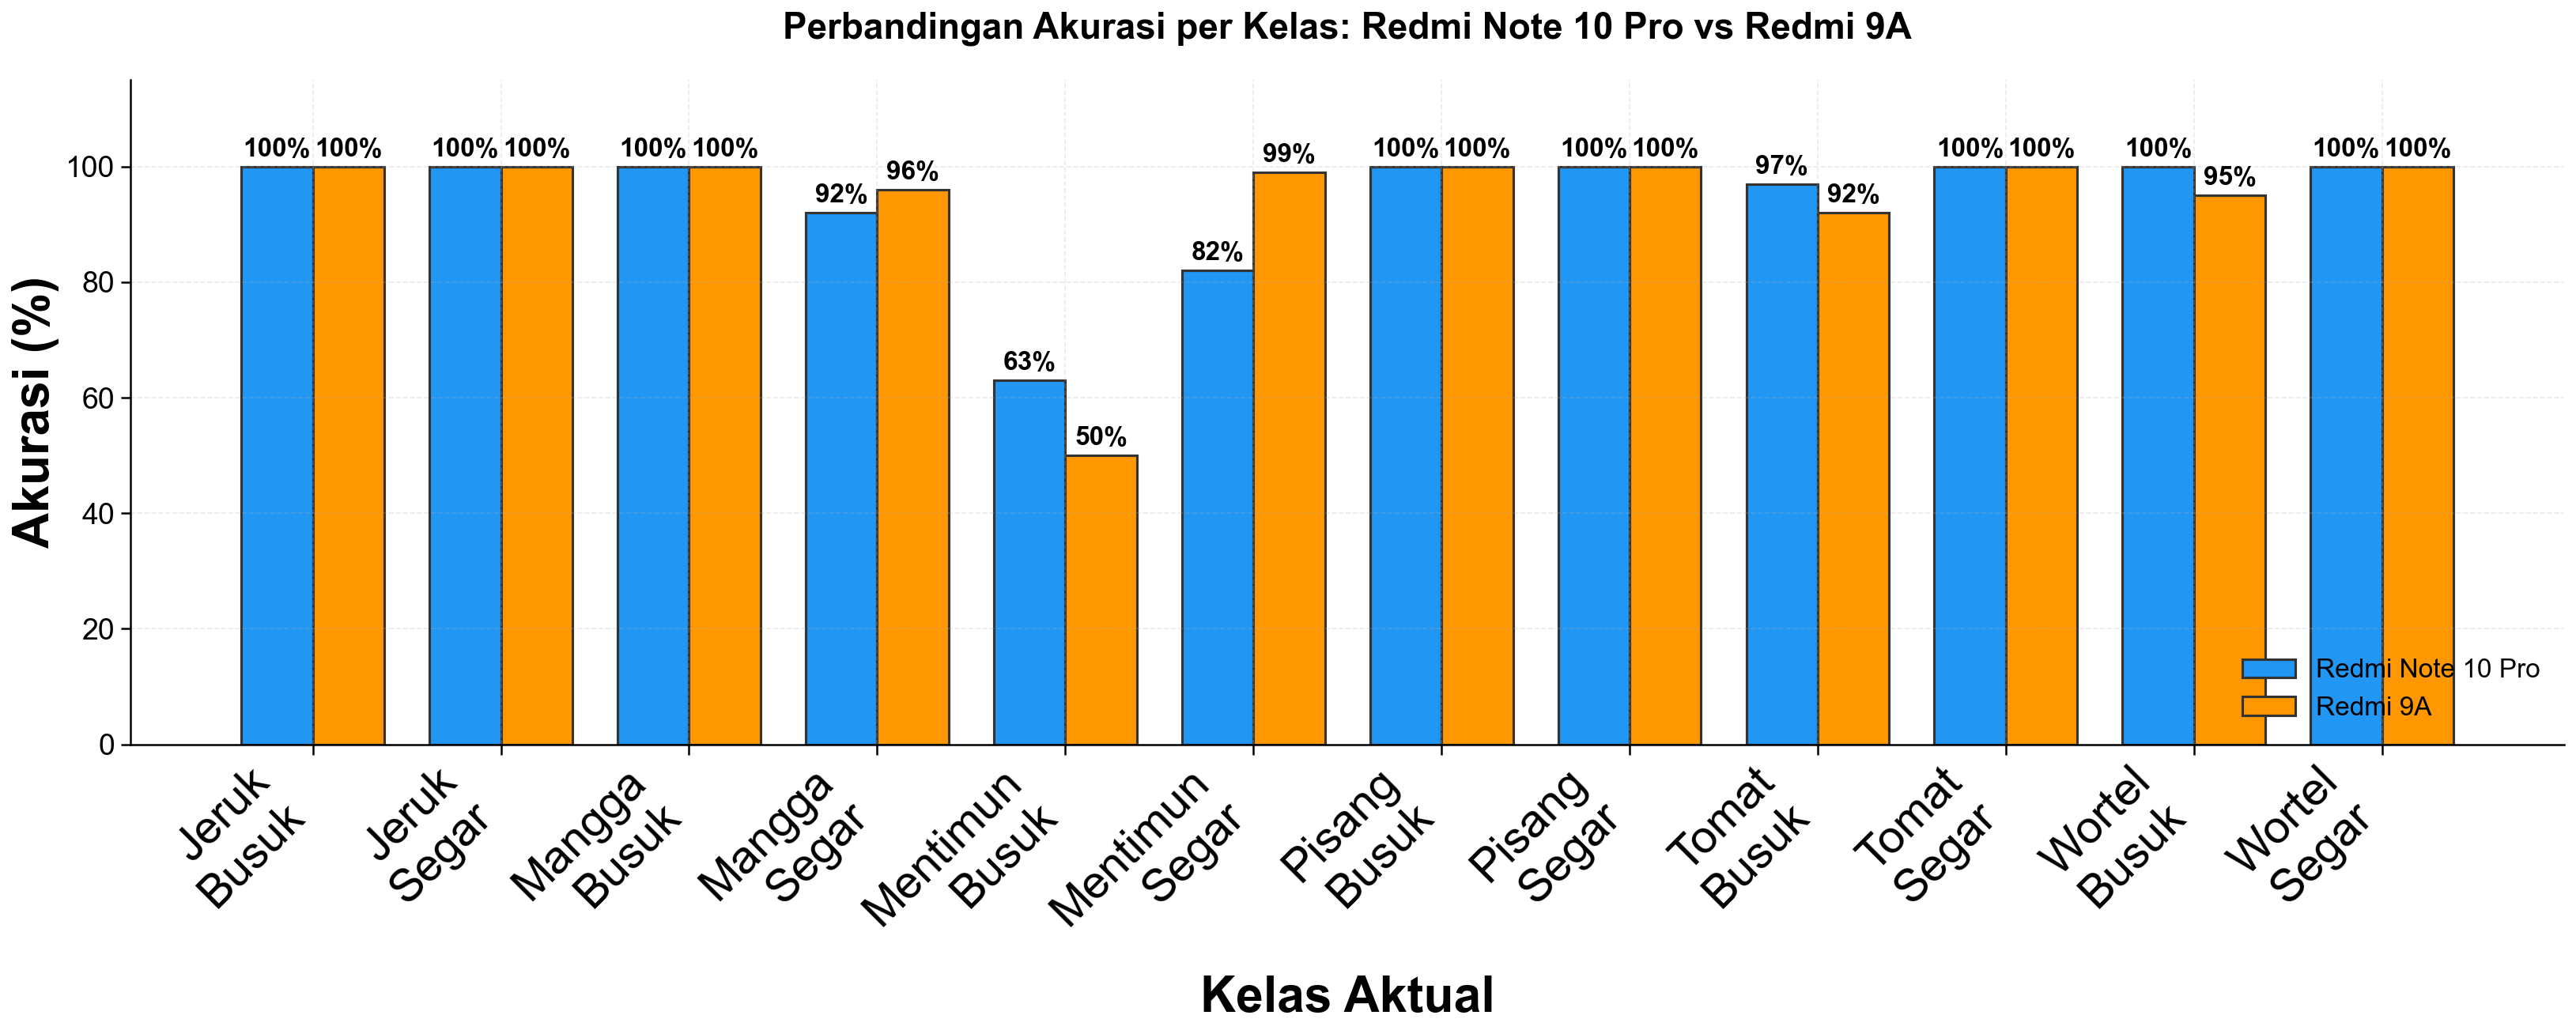

  ✓ Disimpan: 03_perbandingan_akurasi_antar_perangkat.png


WindowsPath('c:/Users/Muhamad Muslih/Desktop/CnnFreshScanResearch/outputs/visualisasi_skripsi/03_perbandingan_akurasi_antar_perangkat.png')

In [22]:
# Merge akurasi kedua perangkat
merge_acc = pd.merge(
    ring_note[["Kelas Aktual", "Akurasi (%)"]].rename(columns={"Akurasi (%)": "Note 10 Pro"}),
    ring_9a  [["Kelas Aktual", "Akurasi (%)"]].rename(columns={"Akurasi (%)": "Redmi 9A"}),
    on="Kelas Aktual", how="outer"
).fillna(0)
merge_acc = merge_acc.set_index("Kelas Aktual").reindex(KELAS_ORDER).reset_index()

x_g   = np.arange(len(merge_acc))
width = 0.38

fig, ax = plt.subplots(figsize=(22, 9))
b1 = ax.bar(x_g - width/2, merge_acc["Note 10 Pro"], width, color=PALETTE["note10"],
            edgecolor="#333", linewidth=1.5, label="Redmi Note 10 Pro")
b2 = ax.bar(x_g + width/2, merge_acc["Redmi 9A"],   width, color=PALETTE["redmi9a"],
            edgecolor="#333", linewidth=1.5, label="Redmi 9A")

for bar, val in zip(b1, merge_acc["Note 10 Pro"]):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.8,
                f"{val:.0f}%", ha="center", va="bottom", fontsize=FONT_CFG["stacked_inside"], fontweight="bold")
for bar, val in zip(b2, merge_acc["Redmi 9A"]):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.8,
                f"{val:.0f}%", ha="center", va="bottom", fontsize=FONT_CFG["stacked_inside"], fontweight="bold")

ax.set_title("Perbandingan Akurasi per Kelas: Redmi Note 10 Pro vs Redmi 9A", fontsize=FONT_CFG["title"], fontweight="bold", pad=25)
ax.set_xlabel("Kelas Aktual", fontsize=FONT_CFG["axis_label"], fontweight="bold")
ax.set_ylabel("Akurasi (%)", fontsize=FONT_CFG["axis_label"], fontweight="bold")
ax.set_ylim(0, 115)
ax.set_xticks(x_g)
ax.set_xticklabels(label_wrap(KELAS_ORDER), fontsize=FONT_CFG["tick_label"], rotation=45, ha="right")
ax.legend(loc="lower right", fontsize=FONT_CFG["legend"])
fig.subplots_adjust(bottom=0.25)

simpan_gambar(fig, "03_perbandingan_akurasi_antar_perangkat.png")



## 8. Grafik Perbandingan Inferensi per Kelas (Gambar 4.38)


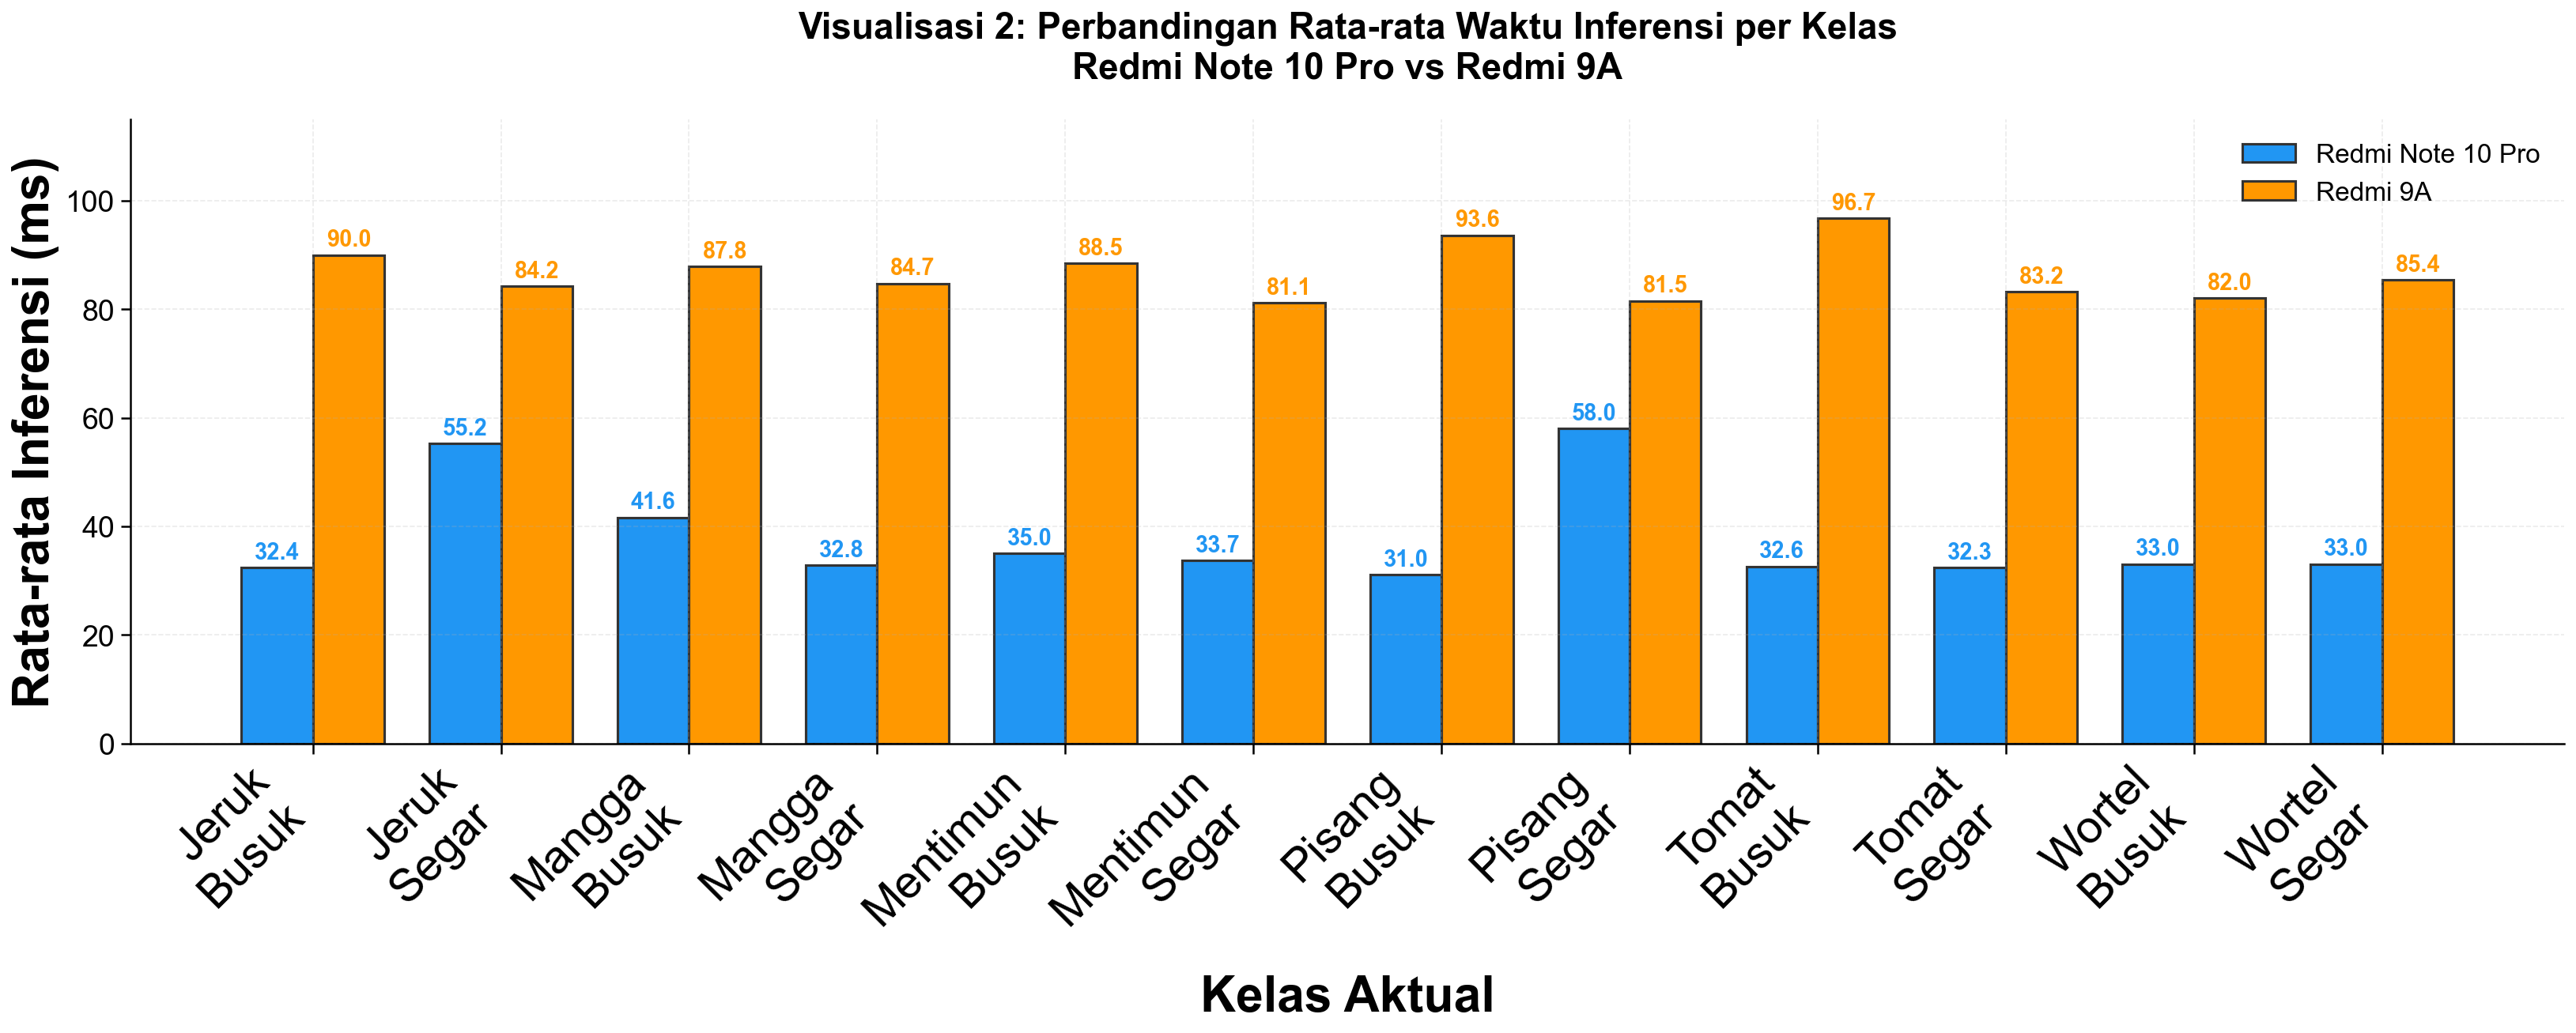

  ✓ Disimpan: 08_bar_rata_inference_perbandingan.png


WindowsPath('c:/Users/Muhamad Muslih/Desktop/CnnFreshScanResearch/outputs/visualisasi_skripsi/08_bar_rata_inference_perbandingan.png')

In [23]:
# Rata-rata inference per kelas untuk kedua perangkat
merge_inf = pd.merge(
    ring_note[["Kelas Aktual", "Rata-rata Inference (ms)"]].rename(
        columns={"Rata-rata Inference (ms)": "Note 10 Pro"}),
    ring_9a[["Kelas Aktual", "Rata-rata Inference (ms)"]].rename(
        columns={"Rata-rata Inference (ms)": "Redmi 9A"}),
    on="Kelas Aktual", how="outer"
).fillna(0)
merge_inf = merge_inf.set_index("Kelas Aktual").reindex(KELAS_ORDER).reset_index()

x_g   = np.arange(len(merge_inf))
width = 0.38

fig, ax = plt.subplots(figsize=(22, 9))
b1 = ax.bar(x_g - width/2, merge_inf["Note 10 Pro"], width, color=PALETTE["note10"],
            edgecolor="#333", linewidth=1.5, label="Redmi Note 10 Pro")
b2 = ax.bar(x_g + width/2, merge_inf["Redmi 9A"],   width, color=PALETTE["redmi9a"],
            edgecolor="#333", linewidth=1.5, label="Redmi 9A")

for bar, val in zip(b1, merge_inf["Note 10 Pro"]):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.8,
                f"{val:.1f}", ha="center", va="bottom", fontsize=FONT_CFG["bar_annotation"], 
                color=PALETTE["note10"], fontweight="bold")
for bar, val in zip(b2, merge_inf["Redmi 9A"]):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.8,
                f"{val:.1f}", ha="center", va="bottom", fontsize=FONT_CFG["bar_annotation"], 
                color=PALETTE["redmi9a"], fontweight="bold")

ax.set_title("Visualisasi 2: Perbandingan Rata-rata Waktu Inferensi per Kelas\nRedmi Note 10 Pro vs Redmi 9A", 
             fontsize=FONT_CFG["title"], fontweight="bold", pad=25)
ax.set_xlabel("Kelas Aktual", fontsize=FONT_CFG["axis_label"], fontweight="bold")
ax.set_ylabel("Rata-rata Inferensi (ms)", fontsize=FONT_CFG["axis_label"], fontweight="bold")
ax.set_ylim(0, 115)
ax.set_xticks(x_g)
ax.set_xticklabels(label_wrap(KELAS_ORDER), fontsize=FONT_CFG["tick_label"], rotation=45, ha="right")
ax.legend(loc="upper right", fontsize=FONT_CFG["legend"])

fig.subplots_adjust(bottom=0.25)
simpan_gambar(fig, "08_bar_rata_inference_perbandingan.png")



## 9. Ringkasan Output File


In [24]:
print('\n' + '='*60)
print('Visualisasi selesai. Output tersimpan di:')
print(f'  {OUTPUT_DIR}')
print('='*60)
import os
output_files = sorted(os.listdir(OUTPUT_DIR))
for f in output_files:
    if f.endswith('.png') or f.endswith('.csv'):
        print(f'  - {f}')




Visualisasi selesai. Output tersimpan di:
  c:\Users\Muhamad Muslih\Desktop\CnnFreshScanResearch\outputs\visualisasi_skripsi
  - 03_perbandingan_akurasi_antar_perangkat.png
  - 08_bar_rata_inference_perbandingan.png
  - tabel_metrik_perbandingan_perangkat.csv
  - tabel_ringkasan_note10pro.csv
  - tabel_ringkasan_redmi9a.csv
